# Evolution of AI: MicroDegree Workshop - 12th Sept 2026

AI evolved because earlier solutions were not enough for newer and more complex problems.

1. Rule-Based AI
2. Machine Learning
3. Generative AI
4. Simple RAG
4. Agentic AI

**Principle:** Always start with the simplest solution possible.


## 1. Rule-Based Systems: Typhoid Symptom Checker

Rule-Based AI follows explicit human-written instructions to make decisions.

In [1]:
def typhoid_rule_system(body_temperature, cough, abdominal_pain,
                       diarrhea, headache, weakness):
    if body_temperature >= 102 and abdominal_pain and diarrhea:
        return "Possible typhoid-like symptom pattern. Please consult a healthcare professional."

    if body_temperature >= 101 and headache and weakness:
        return "Fever-related symptoms detected. Please consult a healthcare professional."

    if cough and body_temperature >= 100:
        return "Fever and cough detected. Please consult a healthcare professional."

    return "No matching rule. Seek medical advice if symptoms continue."

In [2]:
body_temperature = 103
cough = False
abdominal_pain = True
diarrhea = True
headache = True
weakness = True

result = typhoid_rule_system(body_temperature, cough, abdominal_pain, diarrhea, headache, weakness)
print("System response:", result)

System response: Possible typhoid-like symptom pattern. Please consult a healthcare professional.


### Why evolve?

Rules only handle situations that programmers have anticipated. Real-world symptoms can appear in many combinations, so maintaining rules becomes difficult.

## 2. Machine Learning: Height Predicts Weight

Machine Learning learns a relationship from examples instead of requiring every rule to be written manually.

Here we use **linear regression** with:

- One input variable: height
- One target variable: weight

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

np.random.seed(42)

height = np.random.uniform(150, 195, 100)
weight = 0.75 * height - 80 + np.random.normal(0, 5, 100)

people = pd.DataFrame({
    "height_cm": height,
    "weight_kg": weight
})

people.head()

,height_cm,weight_kg
0,166.854305,45.575964
1,192.782144,63.091571
2,182.939727,57.663599
3,176.939632,42.766879
4,157.020839,36.667270


### Before fitting the model

The data contains height and weight examples, but the model has not learned the relationship yet.

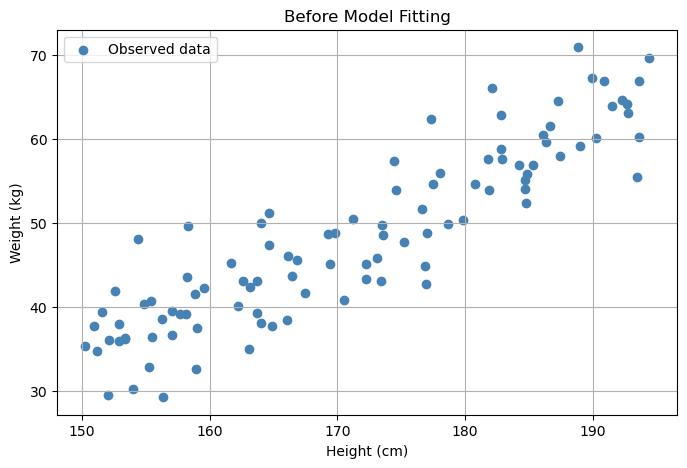

In [4]:
plt.figure(figsize=(8, 5))

plt.scatter(
    people["height_cm"],
    people["weight_kg"],
    color="steelblue",
    label="Observed data"
)

plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("Before Model Fitting")
plt.legend()
plt.grid(True)
plt.show()

### Fit the linear regression model

The model will learn the best straight line for predicting weight from height.

In [5]:
X = people[["height_cm"]]
y = people["weight_kg"]

model = LinearRegression()
model.fit(X, y)

predicted_weight = model.predict(X)

print(f"Slope: {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"Mean squared error: {mean_squared_error(y, predicted_weight):.2f}")

Slope: 0.70
Intercept: -71.26
Mean squared error: 20.16


### After fitting the model

The red line is the relationship learned from the examples.

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


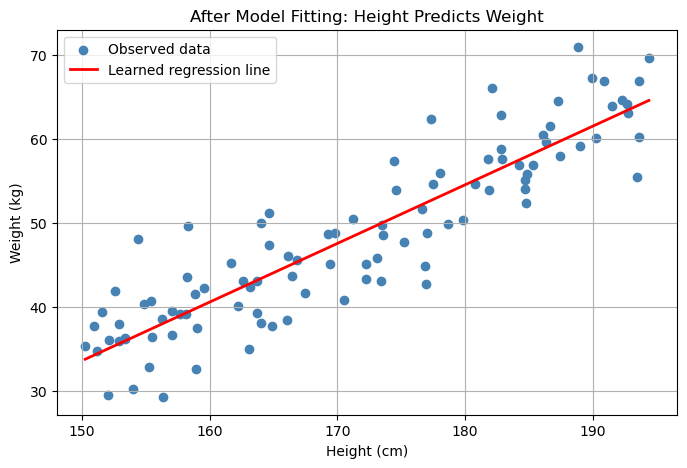

In [6]:
height_values = np.linspace(
    people["height_cm"].min(),
    people["height_cm"].max(),
    100
).reshape(-1, 1)

weight_predictions = model.predict(height_values)

plt.figure(figsize=(8, 5))

plt.scatter(
    people["height_cm"],
    people["weight_kg"],
    color="steelblue",
    label="Observed data"
)

plt.plot(
    height_values,
    weight_predictions,
    color="red",
    linewidth=2,
    label="Learned regression line"
)

plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("After Model Fitting: Height Predicts Weight")
plt.legend()
plt.grid(True)
plt.show()

In [7]:
new_height = pd.DataFrame({"height_cm": [173]})
predicted_weight = model.predict(new_height)[0]

print(f"Predicted weight for 175 cm: {predicted_weight:.1f} kg")

Predicted weight for 175 cm: 49.7 kg


Machine Learning learns a relationship from examples. It is more flexible than manually writing rules, but it only gives a prediction.

## 3. Generative AI

Generative AI creates new content, such as explanations, from the information provided to it.

## 3.1. Configure LLM

In [8]:
import os
import json
from dotenv import load_dotenv
from groq import Groq

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

client = Groq()
model = "openai/gpt-oss-120b"

# from langchain_groq import ChatGroq
# model = ChatGroq(model = "qwen/qwen3.6-27b")

## 3.2. Simple LLM invoke

There are no tools and no memory yet. Each call only knows the messages supplied to it.

In [10]:
messages = [
    {"role": "system", "content": "answer the user query"},
    {"role": "user", "content": "wha is the fav dish in karnataka"},
]

response = client.chat.completions.create(model=model, messages=messages)
# print(response)
print(response.choices[0].message.content)

Karnataka’s cuisine is incredibly diverse, and a few dishes stand out as crowd‑pleasers that many locals consider “the favourite.” The most commonly‑cited **signature dish** is **Bisi Bele Bath**, but the state also boasts several other beloved staples. Below is a quick guide to the top‑rated dishes, what makes them special, and when you’ll typically find them on the table.

---

## 1. Bisi Bele Bath  
**What it is:** A hearty, one‑pot rice‑lentil‑vegetable casserole flavored with a unique spice blend (the *Bisi Bele* powder).  
**Key ingredients:** Rice, toor dal (split pigeon peas), mixed vegetables (carrot, beans, peas, pumpkin), tamarind, ghee, and the spice mix (coriander, cinnamon, cloves, cardamom, dried red chilies, etc.).  
**Why it’s loved:** It’s nutritious, filling, and balances sweet, tangy, and mildly spicy notes. It’s often served with a dollop of ghee, a side of **Raita** (yogurt with cucumber and spices), and a crispy **Papad**.  
**When to eat it:** Breakfast, lunch, 

## 3.3 Simple RAG 

## Load and Split the pdf

In [11]:
from pathlib import Path

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

docs_folder = Path.cwd() / "docs"
pdf_files = list(docs_folder.glob("*.pdf"))

if not pdf_files:
    raise FileNotFoundError(f"No PDF file found in: {docs_folder}")

pdf_path = pdf_files[0]

loader = PyPDFLoader(str(pdf_path))
pages = loader.load()

splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=100
)

documents = splitter.split_documents(pages)

print(f"Loaded PDF: {pdf_path.name}")
print(f"Created chunks: {len(documents)}")

C:\Users\Admin\AppData\Local\Temp\ipykernel_30336\695604008.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


Loaded PDF: Gen AI Curriculum.pdf
Created chunks: 22


## Create the vector database

In [12]:
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_chroma import Chroma

embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

vector_store = Chroma.from_documents(
    documents=documents,
    embedding=embeddings,
    persist_directory="./chroma_db",
    collection_name="pdf_documents"
)

retriever = vector_store.as_retriever(
    search_kwargs={"k": 3}
)

print("PDF chunks embedded and stored in ChromaDB.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

PDF chunks embedded and stored in ChromaDB.


## Retrive relavant chunks

In [ ]:
question = "what is the duration of the course?"

retrieved_documents = retriever.invoke(question)

context = "\n\n".join(
    document.page_content
    for document in retrieved_documents
)

for document in retrieved_documents:
    print(f"Page {document.metadata.get('page', 0) + 1}")
    print(document.page_content[:500])
    print()

Page 17
FEATURE 
Duration
2.5 Months
PREMIUM
PREMIUM PLUS
4.5 Months
Ideal Outcome
AI Application Developer
Agentic AI Engineer

Page 17
0804-710-9999 www.microdegree.workBranches : Bengaluru | Mangaluru
Click to Enrol : https://mdegree.in/curriculum_
Generative AI  
Curriculum
Important:
Experimental / emerging ecosystem 
Applied innovation layer 
Not core architecture foundation
This is positioned as: 
This protects you if the ecosystem shifts.
Premium Plus Plan Outcome
Production-Grade Multi-Agent AI Platform Includes:
Custom RAG 
MCP communication protocol 
Multi-model routing 
Dockerized AWS deployment
(OpenClaw optional ext

Page 18
Visit Our Office 
Visit our office to speak with our academic
counsellors. Getting direct information can
help you feel more confident about your
choices in the program.
Bengaluru Office
Mangaluru Office
MicroDegree Education Private Limited
Sri Guruprasad Vasavi Classic 3rd Floor, 10th Main Rd,
4th Block, Jayanagar, Bengaluru, Karnataka 560011
MicroD

## Generate the response using Groq

In [14]:
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage

llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0
)

messages = [
    SystemMessage(
        content=(
            "Answer only from the provided context. "
            "If the answer is not in the context, say so."
        )
    ),
    HumanMessage(
        content=f"""
Context from the PDF:

{context}

Question:
{question}
"""
    )
]

response = llm.invoke(messages)

print(response.content)

The program offers two tracks:

- **Premium (AI Application Developer)** – **2.5 months**  
- **Premium Plus (Agentic AI Engineer)** – **4.5 months**  

So the course duration is 2.5 months for the Premium track and 4.5 months for the Premium Plus track.


## 4. Agentic AI

An agent:

1. Understands a goal
2. Selects a tool
3. Executes the tool
4. Observes the result
5. Returns a final answer

## Summary

| Approach | Main idea | Limitation |
|---|---|---|
| Rule-Based AI | Humans write rules | Too many rules |
| Machine Learning | Learns from examples | Mainly predicts |
| Generative AI | Creates explanations | May hallucinate |
| Agentic AI | Plans and uses tools | More complex |

**Final principle:** Use the simplest approach that solves the problem. Evolve only when the current approach is no longer sufficient.